# Regressão Logística I
## Tarefa I

Neste exercício vamos trabalhar com a base "Heart Disease Data Set" disponível no site do [UCI](https://archive.ics.uci.edu/ml/datasets/heart+disease).

Temos 303 indivíduos e vamos utilizar 13 variáveis disponíveis para prever a presença de doença cardíaca na variável ```num```(a 14 $^a$ variável).

A descrição das variáveis está recortada abaixo:
- age: idade do paciente em anos
- sex: sexo (1 = male; 0 = female)  
- cp: tipo de dor no peito
  - 1: angina típica
  - 2: angina atípica
  - 3: dor não-angina
  - 4: assintomático
- trestbps: pressão sanguínea em repouso (em mm Hg na admissão ao hospital
- chol: colesterol sérico em mg/dl
- fbs: (açúcar no sangue em jejum > 120 mg/dl) (1 = True; 0 = False)
- restecg: resultados eletrocardiográficos em repouso
  - 0: normal
  - 1: tendo anormalidade da onda ST-T (Inversões de onda T e / ou ST com elevação ou depressão de > 0.05 mV)
  - 2: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de Estes
- thalach: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício(1 = sim; 0 = não)
- oldpeak = Depressão de ST induzida por exercício em relação ao repouso
- slope: Depressão de ST induzida por exercício em relação ao repouso
  - 1: inclinação ascendente
  - 2: estável
  - 3: inclinação descendente
- ca: número de vasos principais (0-3) coloridos por fluorosopia
- thal: 3 = normal; 6 = defeito corrigido; 7 = defeito reversível
- num: diagnóstico de doença cardíaga (status de doença angiográfica)

In [86]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf

In [87]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

df = pd.read_csv(url, 
                 names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [88]:
df['flag_doente'] = (df['num'] != 0).astype('int64')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,flag_doente
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1,1


1. Monte uma bivariada para a variável ```sex``` com as seguintes estatísticas:

- Número de *saudáveis*
- Número de *doentes*
- Total
- Quantidade média de doentes
- *Odds*
- *Odds ratio* (Use o total como referência)
- Logito (LOG(*Odds*))
- O LOG do *Odds ratio* (com o total como referência) é chamado de *Weight of Evidence* (WOE). Calcule-o.

---

* Elaboração de crosstab

In [ ]:
tab0 = (
    pd.crosstab(df["sex"],df["flag_doente"], margins=True)
    .rename(columns={'All': 'Total'},index={0.0:'F', 1.0:'M','All':'Total'} )
    .rename_axis(index="Sexo", columns="Diagnosticados")
)
tab0

Diagnosticados,0,1,Total
Sexo,,,
F,72,25,97
M,92,114,206
Total,164,139,303


Determinação da média de casos diagnosticados

In [ ]:
tab0['mean_diagnosticos']=round(np.mean(tab0.loc[:,tab0.columns != 'Total'], axis=1), 2) # Calculado a média das variáveus 0 e 1, excluindo a coluna 'Total'
tab0

Diagnosticados,0,1,Total,mean_diagnosticos
Sexo,,,,
F,72,25,97,48.5
M,92,114,206,103.0
Total,164,139,303,151.5


Criação das odds para o risco de diagnóstico

In [91]:
tab0['Odds'] = tab0[1] / tab0[0]
tab0

Diagnosticados,0,1,Total,mean_diagnosticos,Odds
Sexo,,,,,
F,72,25,97,48.5,0.347222
M,92,114,206,103.0,1.239130
Total,164,139,303,151.5,0.847561


Odds Ratio (Utilizando o Total como casela de referência)

In [92]:
tab0['Odd_ratio vs Total'] = tab0['Odds'] / tab0.loc['Total', 'Odds']
tab0

Diagnosticados,0,1,Total,mean_diagnosticos,Odds,Odd_ratio vs Total
Sexo,,,,,,
F,72,25,97,48.5,0.347222,0.409672
M,92,114,206,103.0,1.239130,1.461996
Total,164,139,303,151.5,0.847561,1.000000


In [93]:
tab0 = tab0.reindex(columns=[0, 1, 'mean_diagnosticos', 'Odds', 'Odd_ratio vs Total', 'Total'])
tab0

Diagnosticados,0,1,mean_diagnosticos,Odds,Odd_ratio vs Total,Total
Sexo,,,,,,
F,72,25,48.5,0.347222,0.409672,97
M,92,114,103.0,1.239130,1.461996,206
Total,164,139,151.5,0.847561,1.000000,303


2. Monte uma bivariada para a variável ```age``` com as seguintes estatísticas:
- Categorize a variável em 5 grupos
- Calcule as mesmas quantidades calculadas no execício anterior
- Calcule também o valor médio da variável ```age```

---

In [94]:
df['cat_age'] = pd.qcut(df['age'], 5)

In [95]:
tab1 = (
    pd.crosstab(df["cat_age"], df["flag_doente"], margins=True)
    .rename(
        columns={"All": "Total"},
        index={
            "All": "Total",
            pd.Interval(28.999, 45.0): "Dos 28 aos 45 anos",
            pd.Interval(45.0, 53.0): "Dos 45 aos 53 anos",
            pd.Interval(53.0, 58.0): "Dos 53 aos 58 anos",
            pd.Interval(58.0, 62.0): "Dos 58 aos 62 anos",
            pd.Interval(62.0, 77.0): "Dos 66 aos 77 anoos",
        },
    )
    .rename_axis(index="Grupos de idade", columns="Diagnosticados")
)
tab1.index = tab1.index.astype(str)
tab1

Diagnosticados,0,1,Total
Grupos de idade,,,
Dos 28 aos 45 anos,47,16,63
Dos 45 aos 53 anos,42,22,64
Dos 53 aos 58 anos,32,39,71
Dos 58 aos 62 anos,13,32,45
Dos 66 aos 77 anoos,30,30,60
Total,164,139,303


Determinação da média de casos diagnosticados

In [ ]:
tab1['mean_diagnosticos'] = np.mean(tab1.loc[:,tab1.columns != 'Total'], axis=1) # Calculado a média das variáveus 0 e 1, excluindo a coluna 'Total'
tab1

Diagnosticados,0,1,Total,mean_diagnosticos
Grupos de idade,,,,
Dos 28 aos 45 anos,47,16,63,31.5
Dos 45 aos 53 anos,42,22,64,32.0
Dos 53 aos 58 anos,32,39,71,35.5
Dos 58 aos 62 anos,13,32,45,22.5
Dos 66 aos 77 anoos,30,30,60,30.0
Total,164,139,303,151.5


Criação das odds para o risco de diagnóstico

In [98]:
tab1['Odds'] = tab1[1] / tab1[0]
tab1

Diagnosticados,0,1,Total,mean_diagnosticos,Odds
Grupos de idade,,,,,
Dos 28 aos 45 anos,47,16,63,31.5,0.340426
Dos 45 aos 53 anos,42,22,64,32.0,0.523810
Dos 53 aos 58 anos,32,39,71,35.5,1.218750
Dos 58 aos 62 anos,13,32,45,22.5,2.461538
Dos 66 aos 77 anoos,30,30,60,30.0,1.000000
Total,164,139,303,151.5,0.847561


Odds Ratio (Utilizando o Total como casela de referência)

In [99]:
tab1['Odd_ratio vs Total'] = tab1['Odds'] / tab1.loc['Total', 'Odds']
tab1

Diagnosticados,0,1,Total,mean_diagnosticos,Odds,Odd_ratio vs Total
Grupos de idade,,,,,,
Dos 28 aos 45 anos,47,16,63,31.5,0.340426,0.401653
Dos 45 aos 53 anos,42,22,64,32.0,0.523810,0.618020
Dos 53 aos 58 anos,32,39,71,35.5,1.218750,1.437950
Dos 58 aos 62 anos,13,32,45,22.5,2.461538,2.904261
Dos 66 aos 77 anoos,30,30,60,30.0,1.000000,1.179856
Total,164,139,303,151.5,0.847561,1.000000


In [100]:
tab1 = tab1.reindex(columns=[0, 1, 'mean_diagnosticos', 'Odds', 'Odd_ratio vs Total', 'Total'])
tab1

Diagnosticados,0,1,mean_diagnosticos,Odds,Odd_ratio vs Total,Total
Grupos de idade,,,,,,
Dos 28 aos 45 anos,47,16,31.5,0.340426,0.401653,63
Dos 45 aos 53 anos,42,22,32.0,0.523810,0.618020,64
Dos 53 aos 58 anos,32,39,35.5,1.218750,1.437950,71
Dos 58 aos 62 anos,13,32,22.5,2.461538,2.904261,45
Dos 66 aos 77 anoos,30,30,30.0,1.000000,1.179856,60
Total,164,139,151.5,0.847561,1.000000,303


3. Visualize a informação da bivariada construída acima através de um gráfico da sua escolha.

In [101]:
df.head(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,flag_doente,cat_age
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0,"(62.0, 77.0]"
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1,"(62.0, 77.0]"
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1,"(62.0, 77.0]"


In [102]:
tab1.index

Index(['Dos 28 aos 45 anos', 'Dos 45 aos 53 anos', 'Dos 53 aos 58 anos',
       'Dos 58 aos 62 anos', 'Dos 66 aos 77 anoos', 'Total'],
      dtype='object', name='Grupos de idade')

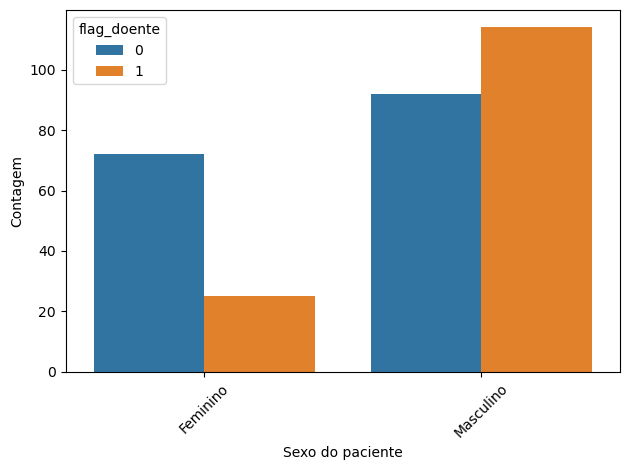

In [103]:
ax = sns.countplot(data=df,  x='sex',hue='flag_doente')

plt.xticks(
    ticks=range(2),  
    labels=['Feminino', 'Masculino'],
    rotation=45  
)

ax.set_ylabel('Contagem')
ax.set_xlabel('Sexo do paciente')

plt.tight_layout()  
plt.show()

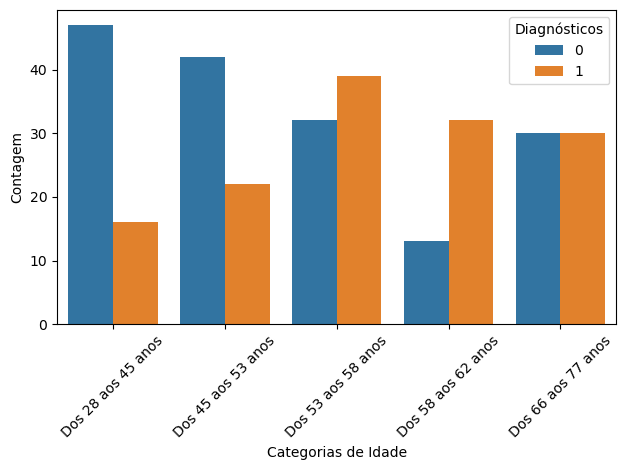

In [104]:

ax = sns.countplot(data=df, hue='flag_doente', x='cat_age')


plt.xticks(
    ticks=range(5),  
    labels=['Dos 28 aos 45 anos', 'Dos 45 aos 53 anos', 'Dos 53 aos 58 anos',
            'Dos 58 aos 62 anos', 'Dos 66 aos 77 anos'],
    rotation=45  
)

ax.set_ylabel('Contagem')
ax.set_xlabel('Categorias de Idade')
ax.legend().set_title('Diagnósticos')

plt.tight_layout()  
plt.show()


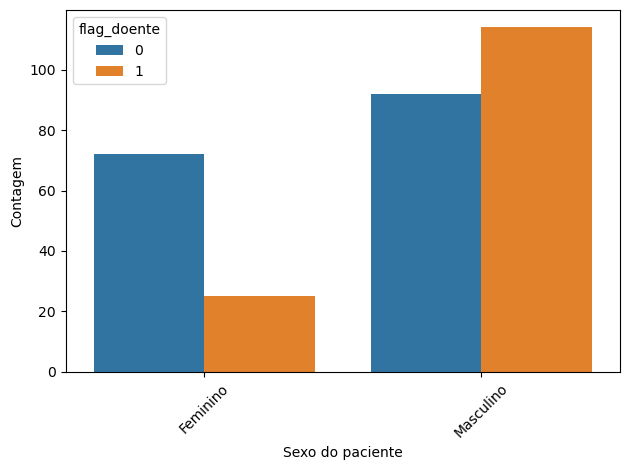

In [105]:
ax = sns.countplot(data=df,  x='sex',hue='flag_doente')

plt.xticks(
    ticks=range(2),  
    labels=['Feminino', 'Masculino'],
    rotation=45  
)

ax.set_ylabel('Contagem')
ax.set_xlabel('Sexo do paciente')

plt.tight_layout()  
plt.show()

<Axes: xlabel='Sexo'>

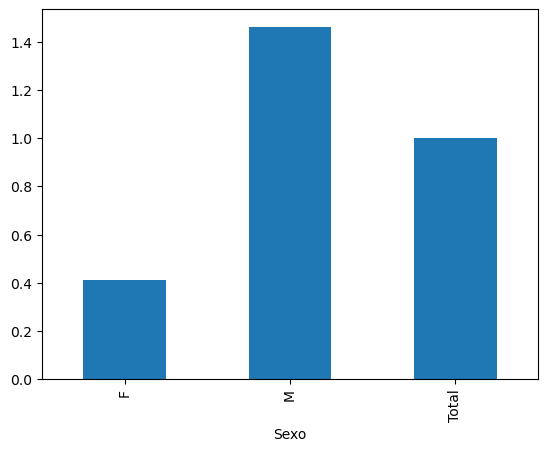

In [106]:
tab0['Odd_ratio vs Total'].plot.bar()

<Axes: xlabel='Grupos de idade'>

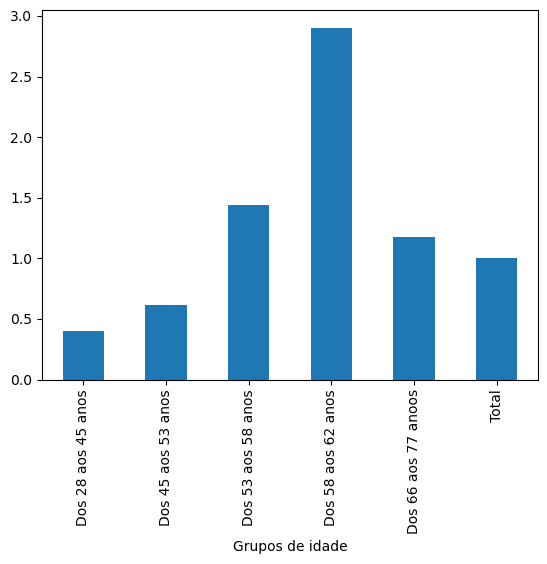

In [107]:
tab1['Odd_ratio vs Total'].plot.bar()

In [108]:
tab1_reset = tab1.reset_index()
colunas_para_melt = [0, 1]
colunas_para_manter = ['Grupos de idade',"mean_diagnosticos", "Odds", "Odd_ratio vs Total", "Total"]
tab1_melted = tab1_reset.melt(
    id_vars=["Grupos de idade"],
    var_name="Diagnosticos",
    value_vars=colunas_para_melt,
    value_name="Estatísticas",
)

tab1_visual = tab1_melted.merge(tab1_reset[colunas_para_manter], on='Grupos de idade')
tab1_visual

,Grupos de idade,Diagnosticos,Estatísticas,mean_diagnosticos,Odds,Odd_ratio vs Total,Total
0,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63
1,Dos 45 aos 53 anos,0,42,32.0,0.523810,0.618020,64
2,Dos 53 aos 58 anos,0,32,35.5,1.218750,1.437950,71
3,Dos 58 aos 62 anos,0,13,22.5,2.461538,2.904261,45
4,Dos 66 aos 77 anoos,0,30,30.0,1.000000,1.179856,60
5,Total,0,164,151.5,0.847561,1.000000,303
6,Dos 28 aos 45 anos,1,16,31.5,0.340426,0.401653,63
7,Dos 45 aos 53 anos,1,22,32.0,0.523810,0.618020,64
8,Dos 53 aos 58 anos,1,39,35.5,1.218750,1.437950,71
9,Dos 58 aos 62 anos,1,32,22.5,2.461538,2.904261,45


C:\Users\hfasa\AppData\Local\Temp\ipykernel_2724\3291469540.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


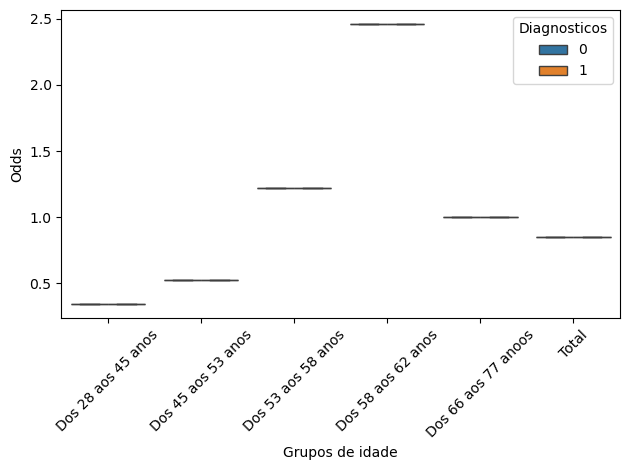

In [109]:
ax = sns.boxplot(data=tab1_visual, x="Grupos de idade", y="Odds", hue="Diagnosticos")

ax.set_xticklabels(
    labels=[
        "Dos 28 aos 45 anos",
        "Dos 45 aos 53 anos",
        "Dos 53 aos 58 anos",
        "Dos 58 aos 62 anos",
        "Dos 66 aos 77 anoos",
        "Total",
    ],
    rotation=45,
    
)

plt.tight_layout()
plt.show()


In [111]:
tab1_visual = tab1_visual.rename(columns={'Diagnosticos': 'flag_doente'})
tab1_visual = tab1_visual.merge(df[['flag_doente', 'age']], on="flag_doente")

In [112]:
tab1_visual

,Grupos de idade,flag_doente,Estatísticas,mean_diagnosticos,Odds,Odd_ratio vs Total,Total,age
0,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63,63.0
1,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63,37.0
2,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63,41.0
3,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63,56.0
4,Dos 28 aos 45 anos,0,47,31.5,0.340426,0.401653,63,57.0
...,...,...,...,...,...,...,...,...
1813,Total,1,139,151.5,0.847561,1.000000,303,57.0
1814,Total,1,139,151.5,0.847561,1.000000,303,45.0
1815,Total,1,139,151.5,0.847561,1.000000,303,68.0
1816,Total,1,139,151.5,0.847561,1.000000,303,57.0


C:\Users\hfasa\AppData\Local\Temp\ipykernel_2724\2468455312.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


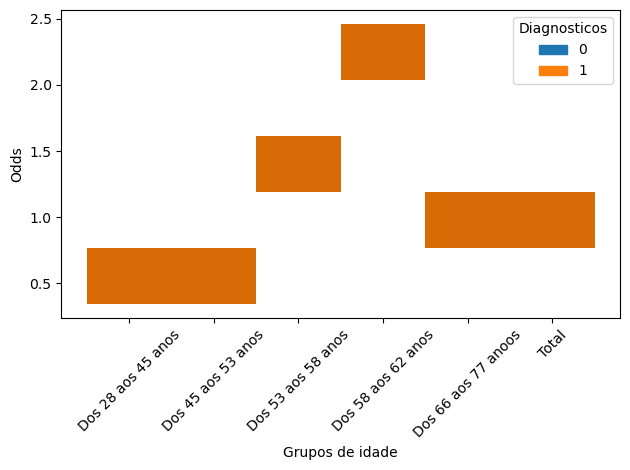

In [110]:
ax = sns.histplot(data=tab1_visual, x="Grupos de idade", y="Odds", hue="flag_doente")

ax.set_xticklabels(
    labels=[
        "Dos 28 aos 45 anos",
        "Dos 45 aos 53 anos",
        "Dos 53 aos 58 anos",
        "Dos 58 aos 62 anos",
        "Dos 66 aos 77 anoos",
        "Total",
    ],
    rotation=45,
    
)

plt.tight_layout()
plt.show()

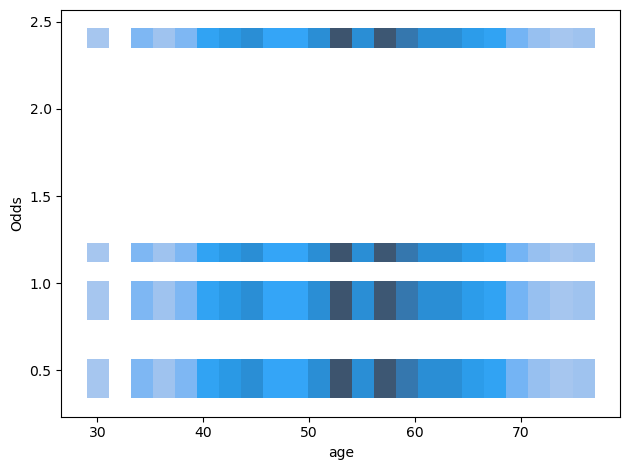

In [125]:
ax = sns.histplot(data=tab1_visual, x="age", y="Odds")


    

plt.tight_layout()
plt.show()